# Heart Disease Prediction Model

In [1]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set()
plt.style.use('ggplot')
%matplotlib inline

In [2]:
#import dataset
heart_df = pd.read_csv('/content/heart.csv')
heart_df.head(10)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
6,58,1,0,114,318,0,2,140,0,4.4,0,3,1,0
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
8,46,1,0,120,249,0,0,144,0,0.8,2,0,3,0
9,54,1,0,122,286,0,0,116,1,3.2,1,2,2,0


In [3]:
# information about the dataset
heart_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
#description about dataset
heart_df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
heart_df.shape

(1025, 14)

# Checking null values

In [6]:
heart_df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [7]:
heart_df.notnull().sum()

,0
age,1025
sex,1025
cp,1025
trestbps,1025
chol,1025
fbs,1025
restecg,1025
thalach,1025
exang,1025
oldpeak,1025


In [8]:
heart_df.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


# Exploratory Data Analysis(EDA)

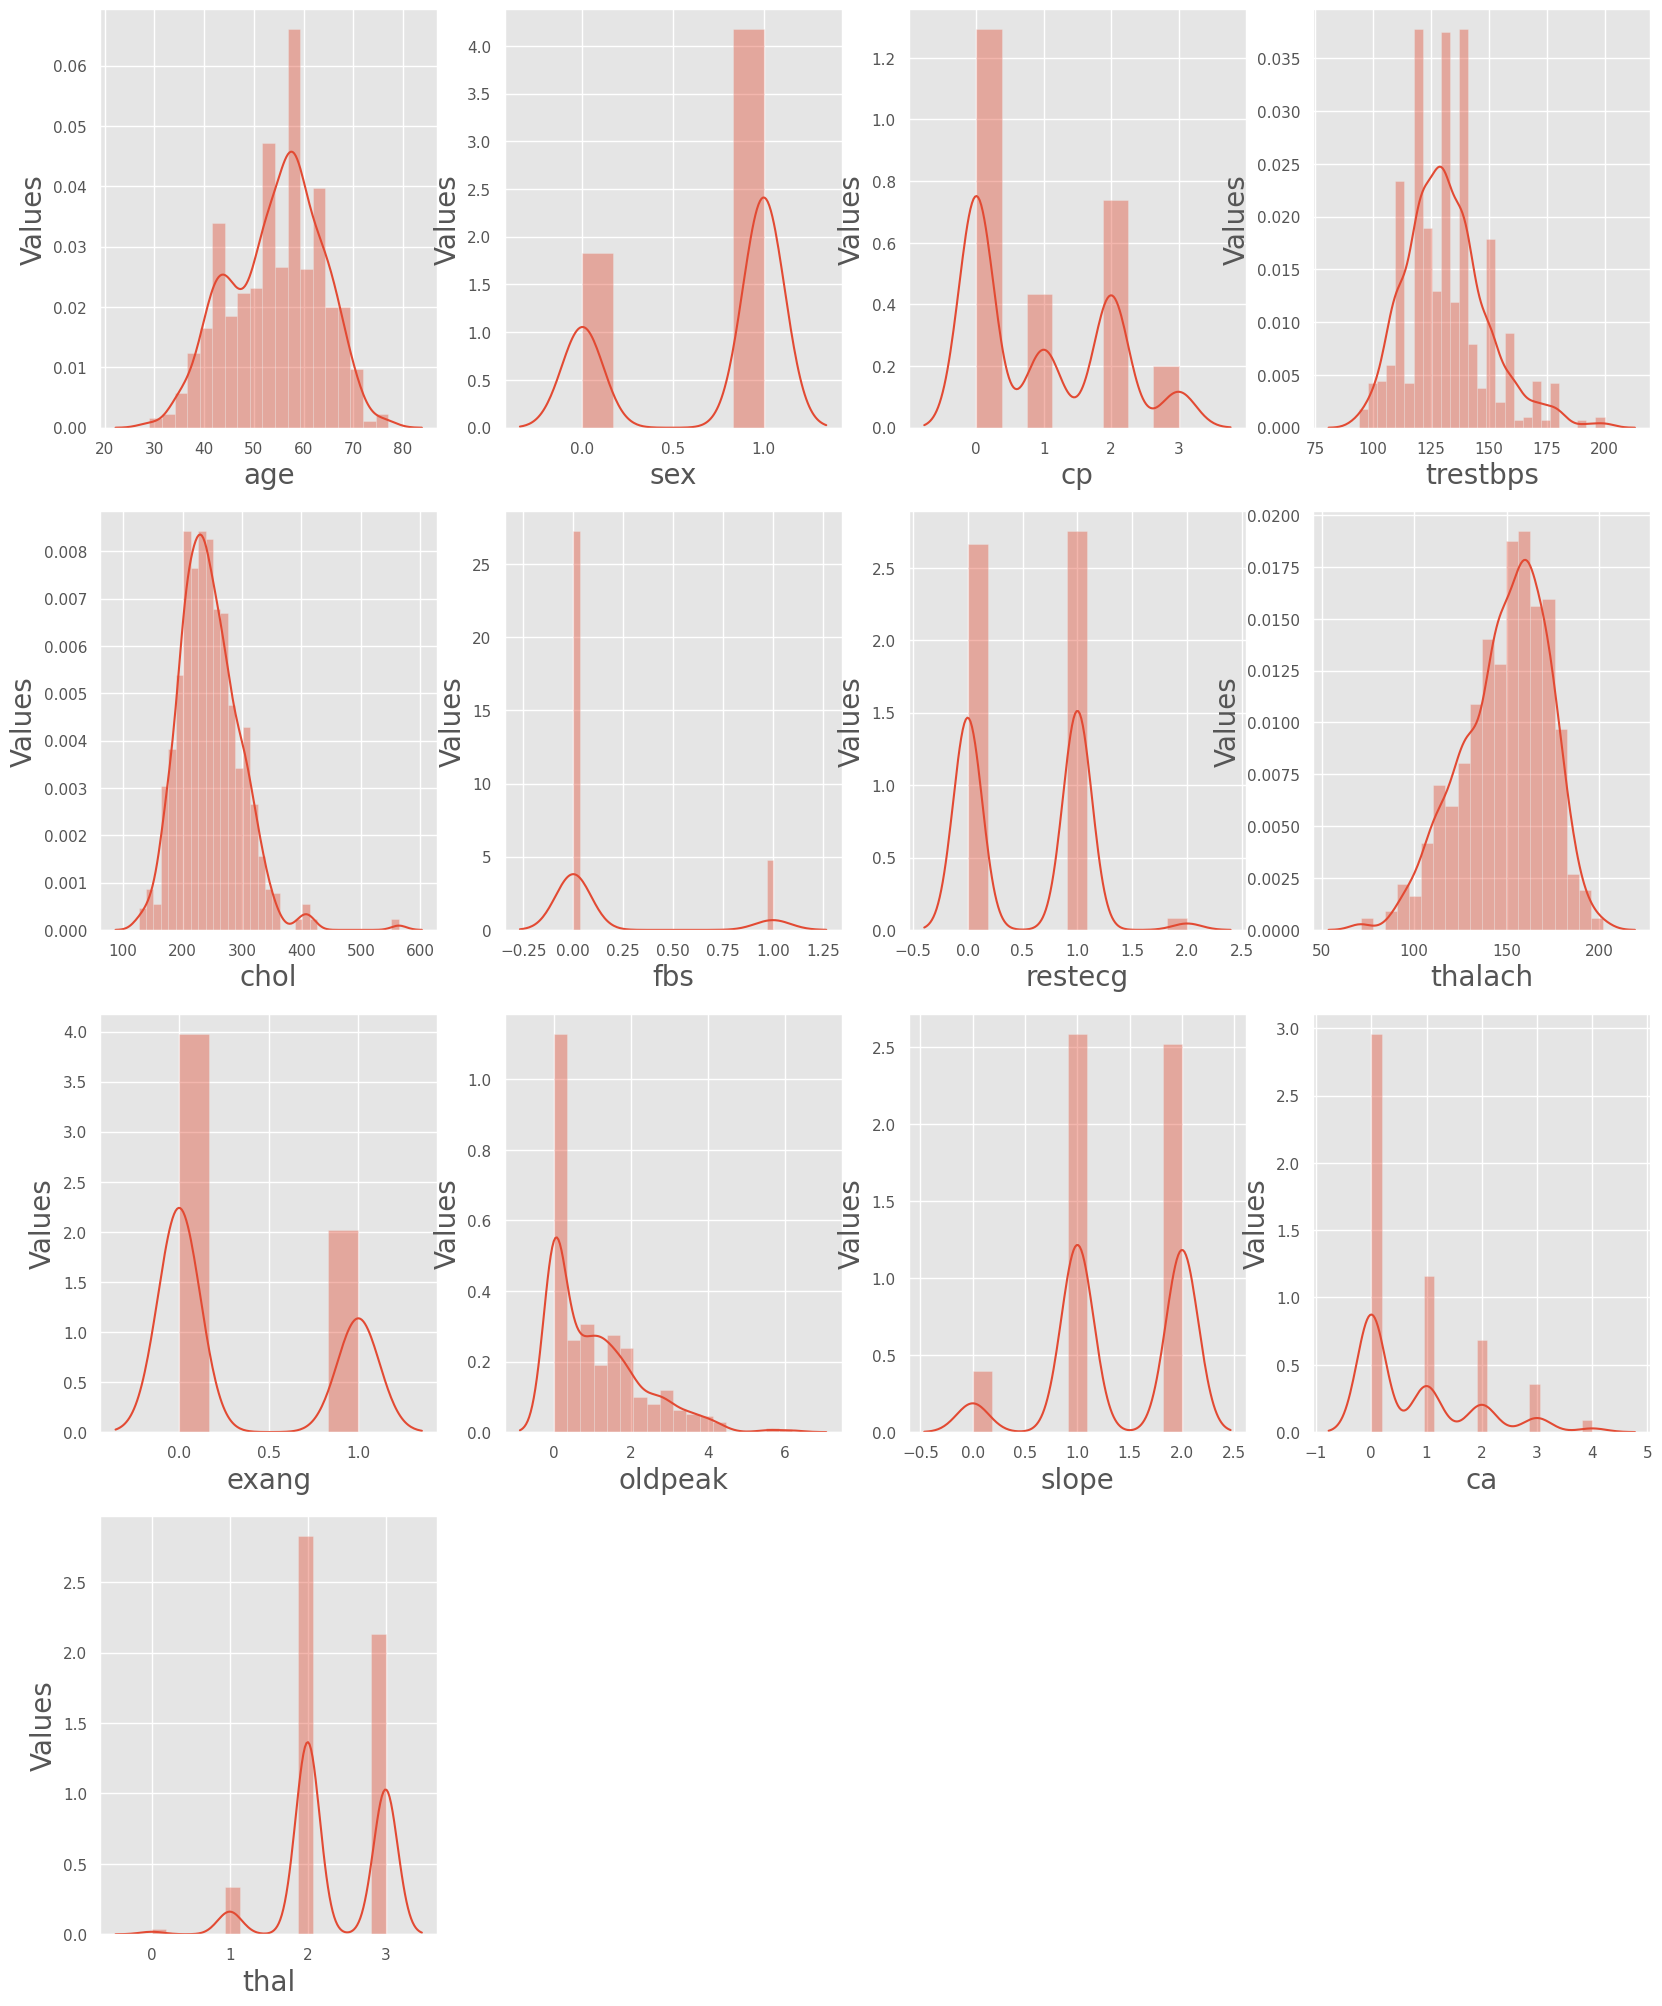

In [9]:
#Plotting the distribution plot.
plt.figure(figsize=(20,25))
plotnumber=1

for column in heart_df:
    if plotnumber<14:
        ax=plt.subplot(4,4,plotnumber)
        sns.distplot(heart_df[column])
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Values',fontsize=20)
    plotnumber+=1
plt.show()

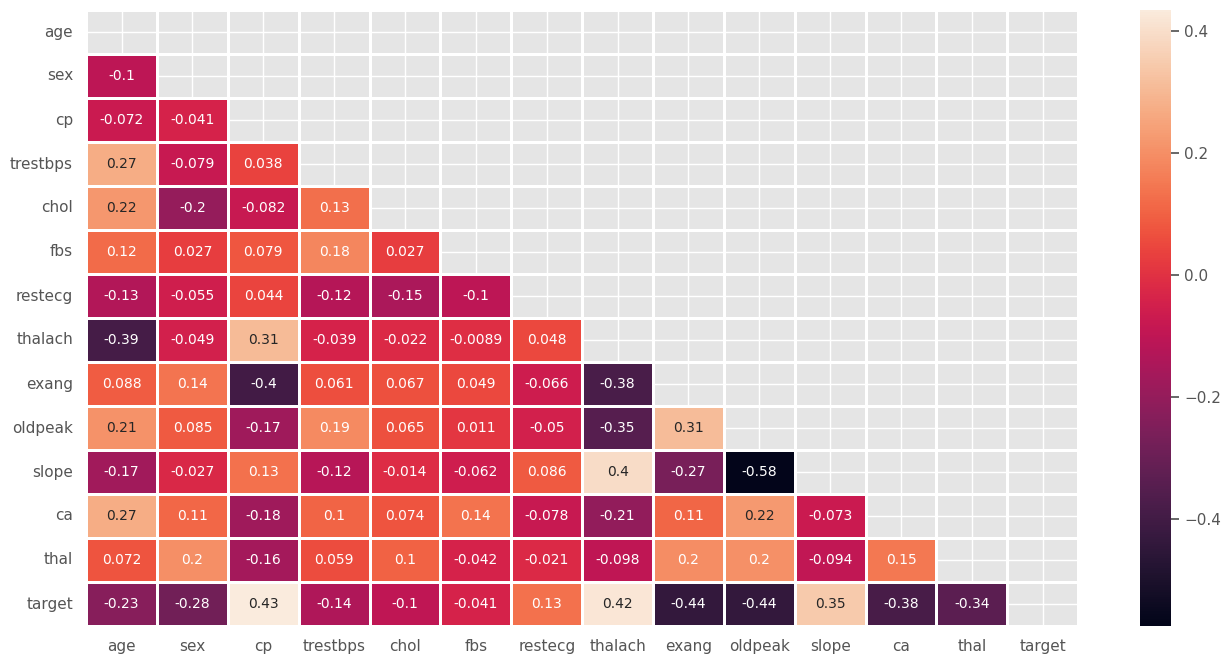

In [10]:
#Correlation matrix

plt.figure(figsize = (16, 8))

corr = heart_df.corr()
mask = np.triu(np.ones_like(corr, dtype = bool))
sns.heatmap(corr, mask = mask, annot = True, fmt = '.2g', linewidths = 1)
plt.show()

In [11]:
#checking the variance
heart_df.var()

,0
age,82.306450
sex,0.211944
cp,1.060160
trestbps,306.835410
chol,2661.787109
fbs,0.127111
restecg,0.278655
thalach,529.263325
exang,0.223514
oldpeak,1.380750


# Normalization

In [12]:
heart_df['trestbps']=np.log(heart_df['trestbps'])
heart_df['chol']=np.log(heart_df['chol'])
heart_df['thalach']=np.log(heart_df['thalach'])

np.var(heart_df[["trestbps",'chol','thalach']])

,0
trestbps,0.016843
chol,0.041430
thalach,0.027516


In [13]:
heart_df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [14]:
x=heart_df.drop('target',axis=1)
y=heart_df['target']

In [15]:
#spliting the dataset into train-test
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x, y, test_size=0.30, random_state=0)

In [16]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   float64
 4   chol      1025 non-null   float64
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   float64
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
dtypes: float64(4), int64(9)
memory usage: 104.2 KB


# Logistic Regression

In [17]:
accuracies={}

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
lr = LogisticRegression(penalty='l2')
lr.fit(x_train,y_train)

y_pred = lr.predict(x_test)

acc=accuracy_score(y_test,y_pred)
accuracies['LR']=acc*100
print("Training accuracy score of the model is:",accuracy_score(y_train, lr.predict(x_train))*100,"%")
print("Testing accuracy score of the model is:",accuracy_score(y_test,y_pred)*100,"%")

Training accuracy score of the model is: 85.49511854951184 %
Testing accuracy score of the model is: 88.31168831168831 %


In [18]:
print("Confusion matrix of the model",confusion_matrix(y_test,y_pred))

print("Classification Report",classification_report(y_test,y_pred))

Confusion matrix of the model [[121  24]
 [ 12 151]]
Classification Report               precision    recall  f1-score   support

           0       0.91      0.83      0.87       145
           1       0.86      0.93      0.89       163

    accuracy                           0.88       308
   macro avg       0.89      0.88      0.88       308
weighted avg       0.88      0.88      0.88       308



# K Nearest Neighbors

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=8)

knn.fit(x_train,y_train)

y_pred1 = knn.predict(x_test)

acc1=accuracy_score(y_test,y_pred1)
accuracies['KNN']=acc1*100

print("Training accuracy score of the model is:",accuracy_score(y_train, knn.predict(x_train))*100,"%")
print("Testing accuracy score of the model is:",accuracy_score(y_test,y_pred1)*100,"%")

Training accuracy score of the model is: 87.86610878661088 %
Testing accuracy score of the model is: 86.03896103896103 %


In [20]:
print("Confusion matrix of the model",confusion_matrix(y_test,y_pred1))

print("Classification Report",classification_report(y_test,y_pred1))

Confusion matrix of the model [[128  17]
 [ 26 137]]
Classification Report               precision    recall  f1-score   support

           0       0.83      0.88      0.86       145
           1       0.89      0.84      0.86       163

    accuracy                           0.86       308
   macro avg       0.86      0.86      0.86       308
weighted avg       0.86      0.86      0.86       308



# SVM

In [21]:
from sklearn.svm import SVC

svc = SVC(probability=True)
svc.fit(x_train, y_train)

y_pred2 = svc.predict(x_test)

acc2=accuracy_score(y_test,y_pred2)
accuracies['SVM']=acc2*100

print("Training accuracy score of the model is:",accuracy_score(y_train, svc.predict(x_train))*100,"%")
print("Testing accuracy score of the model is:",accuracy_score(y_test,y_pred2)*100,"%")

Training accuracy score of the model is: 71.40864714086472 %
Testing accuracy score of the model is: 71.75324675324676 %


In [22]:
print("Confusion matrix of the model",confusion_matrix(y_test,y_pred2))

print("Classification Report",classification_report(y_test,y_pred2))

Confusion matrix of the model [[108  37]
 [ 50 113]]
Classification Report               precision    recall  f1-score   support

           0       0.68      0.74      0.71       145
           1       0.75      0.69      0.72       163

    accuracy                           0.72       308
   macro avg       0.72      0.72      0.72       308
weighted avg       0.72      0.72      0.72       308



# Decision Tree

In [23]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier()
dtc.fit(x_train, y_train)

y_pred3 = dtc.predict(x_test)

acc3=accuracy_score(y_test,y_pred3)
accuracies['DT']=acc3*100

print("Training accuracy score of the model is:",accuracy_score(y_train, dtc.predict(x_train))*100,"%")
print("Testing accuracy score of the model is:",accuracy_score(y_test,y_pred3)*100,"%")

Training accuracy score of the model is: 100.0 %
Testing accuracy score of the model is: 100.0 %


In [24]:
print("Confusion matrix of the model",confusion_matrix(y_test,y_pred3))

print("Classification Report",classification_report(y_test,y_pred3))

Confusion matrix of the model [[145   0]
 [  0 163]]
Classification Report               precision    recall  f1-score   support

           0       1.00      1.00      1.00       145
           1       1.00      1.00      1.00       163

    accuracy                           1.00       308
   macro avg       1.00      1.00      1.00       308
weighted avg       1.00      1.00      1.00       308



In [25]:
from sklearn.model_selection import GridSearchCV

grid_params = {
    'criterion' : ['gini', 'entropy'],
    'max_depth' : range(2, 32, 1),
    'min_samples_leaf' : range(1, 10, 1),
    'min_samples_split' : range(2, 10, 1),
    'splitter' : ['best', 'random']
}

grid_search = GridSearchCV(dtc, grid_params, cv = 10, n_jobs = -1, verbose = 1)
grid_search.fit(x_train, y_train)

Fitting 10 folds for each of 8640 candidates, totalling 86400 fits


GridSearchCV(cv=10, estimator=DecisionTreeClassifier(), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(2, 32),
                         'min_samples_leaf': range(1, 10),
                         'min_samples_split': range(2, 10),
                         'splitter': ['best', 'random']},
             verbose=1)

In [26]:
grid_search.best_score_

np.float64(0.9874021909233177)

In [27]:
grid_search.best_params_

{'criterion': 'gini',
 'max_depth': 19,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'splitter': 'random'}

In [28]:
dtc2 = DecisionTreeClassifier(criterion= 'entropy', max_depth= 12, min_samples_leaf= 1, min_samples_split= 2, splitter= 'random')
dtc2.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=12, splitter='random')

In [29]:
y_pred4 = dtc2.predict(x_test)
acc4=accuracy_score(y_test,y_pred4)
accuracies['DT2']=acc4*100

print("Training accuracy score of the model is:",accuracy_score(y_train, dtc2.predict(x_train))*100,"%")
print("Testing accuracy score of the model is:",accuracy_score(y_test,y_pred4)*100,"%")

Training accuracy score of the model is: 98.74476987447699 %
Testing accuracy score of the model is: 97.40259740259741 %


In [30]:
print("Confusion matrix of the model",confusion_matrix(y_test,y_pred4))

print("Classification Report",classification_report(y_test,y_pred4))

Confusion matrix of the model [[142   3]
 [  5 158]]
Classification Report               precision    recall  f1-score   support

           0       0.97      0.98      0.97       145
           1       0.98      0.97      0.98       163

    accuracy                           0.97       308
   macro avg       0.97      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308



In [31]:
# update dictionary
accuracies['DT']=acc4*100
del accuracies['DT2']

# Random Forest

In [32]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(criterion = 'gini', max_depth = 7, max_features = 'sqrt', min_samples_leaf = 2, min_samples_split = 4, n_estimators = 180)
rfc.fit(x_train, y_train)

y_pred5 = rfc.predict(x_test)

acc5=accuracy_score(y_test,y_pred5)
accuracies['RF']=acc5*100

print("Training accuracy score of the model is:",accuracy_score(y_train, rfc.predict(x_train))*100,"%")
print("Testing accuracy score of the model is:",accuracy_score(y_test,y_pred5)*100,"%")

Training accuracy score of the model is: 98.88423988842399 %
Testing accuracy score of the model is: 97.72727272727273 %


In [33]:
print("Confusion matrix of the model",confusion_matrix(y_test,y_pred5))

print("Classification Report",classification_report(y_test,y_pred5))

Confusion matrix of the model [[139   6]
 [  1 162]]
Classification Report               precision    recall  f1-score   support

           0       0.99      0.96      0.98       145
           1       0.96      0.99      0.98       163

    accuracy                           0.98       308
   macro avg       0.98      0.98      0.98       308
weighted avg       0.98      0.98      0.98       308



# Gradient Boosting

In [34]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

gbc = GradientBoostingClassifier(learning_rate = 0.05, loss = 'log_loss', n_estimators = 180)  # Use 'log_loss' or 'exponential'
gbc.fit(x_train, y_train)

y_pred6 = gbc.predict(x_test)

acc6 = accuracy_score(y_test, y_pred6)
accuracies['GradientBoosting'] = acc6 * 100

print("Training accuracy score of the model is:", accuracy_score(y_train, gbc.predict(x_train)) * 100, "%")
print("Testing accuracy score of the model is:", accuracy_score(y_test, y_pred6) * 100, "%")


Training accuracy score of the model is: 98.60529986052998 %
Testing accuracy score of the model is: 97.72727272727273 %


# XGBoost

In [35]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

xgb = XGBClassifier(objective='binary:logistic',
                    learning_rate=0.01,
                    max_depth=5,
                    n_estimators=180)

xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

acc = accuracy_score(y_test, y_pred)
print("Testing accuracy score of the model is:", acc * 100, "%")


Testing accuracy score of the model is: 97.40259740259741 %


In [36]:
y_pred7 = xgb.predict(x_test)

acc7=accuracy_score(y_test,y_pred7)

accuracies['XGBoost']=acc7*100
print("Training accuracy score of the model is:",accuracy_score(y_train, xgb.predict(x_train))*100,"%")
print("Testing accuracy score of the model is:",accuracy_score(y_test,y_pred7)*100,"%")

Training accuracy score of the model is: 98.18688981868898 %
Testing accuracy score of the model is: 97.40259740259741 %


In [37]:
print("Confusion matrix of the model",confusion_matrix(y_test,y_pred7))

print("Classification Report",classification_report(y_test,y_pred7))

Confusion matrix of the model [[138   7]
 [  1 162]]
Classification Report               precision    recall  f1-score   support

           0       0.99      0.95      0.97       145
           1       0.96      0.99      0.98       163

    accuracy                           0.97       308
   macro avg       0.98      0.97      0.97       308
weighted avg       0.97      0.97      0.97       308



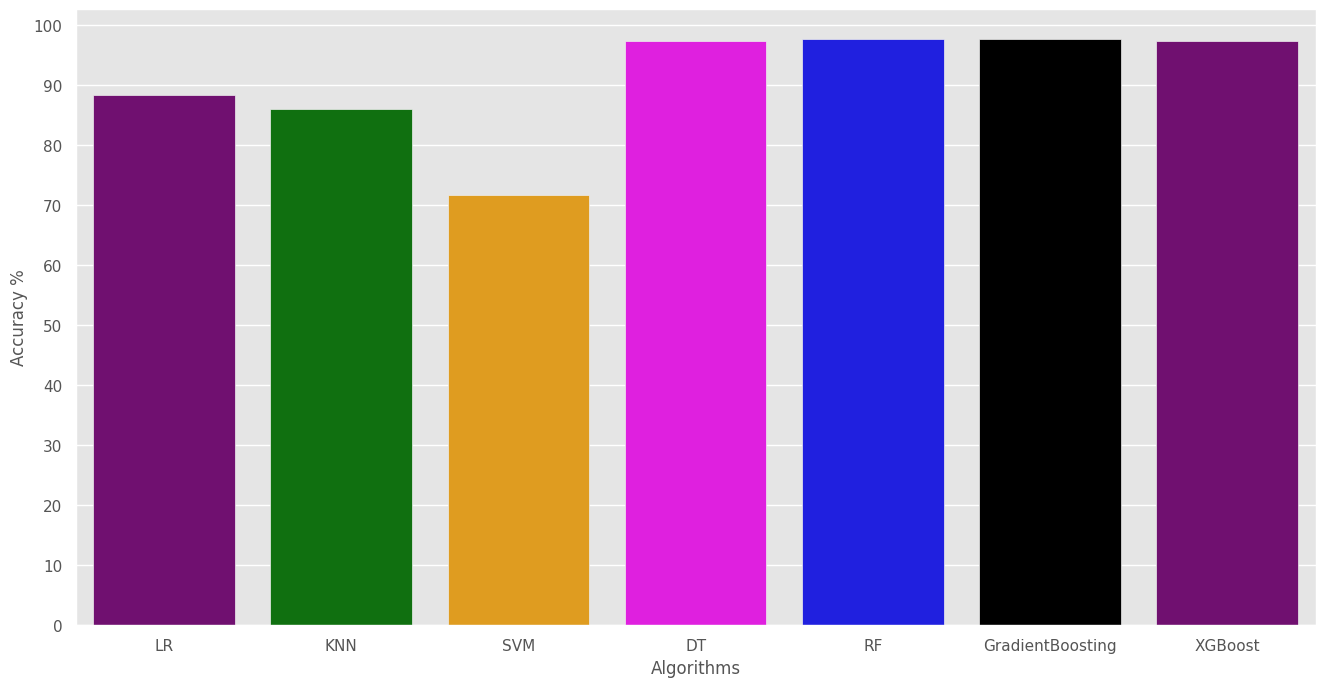

In [38]:
colors = ["purple", "green", "orange", "magenta","blue","black"]

# sns.set_style("whitegrid")
plt.figure(figsize=(16,8))
plt.yticks(np.arange(0,1200,10))
plt.ylabel("Accuracy %")
plt.xlabel("Algorithms")
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette=colors )
plt.show()

In [39]:
models = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'SVM',  'Decision Tree', 'Random Forest', 'Gradient Boosting', 'XgBoost'],
    'Score': [acc, acc1, acc2, acc4, acc5, acc6, acc7]
})

models.sort_values(by = 'Score', ascending = False)

,Model,Score
4,Random Forest,0.977273
5,Gradient Boosting,0.977273
0,Logistic Regression,0.974026
3,Decision Tree,0.974026
6,XgBoost,0.974026
1,KNN,0.860390
2,SVM,0.717532


In [40]:
import pickle
import os

# Create the directory if it doesn't exist
os.makedirs('models', exist_ok=True)

# Assuming rfc is your trained model
model = rfc

# Save the model
with open('models/heart.pkl', 'wb') as f:
    pickle.dump(model, f)


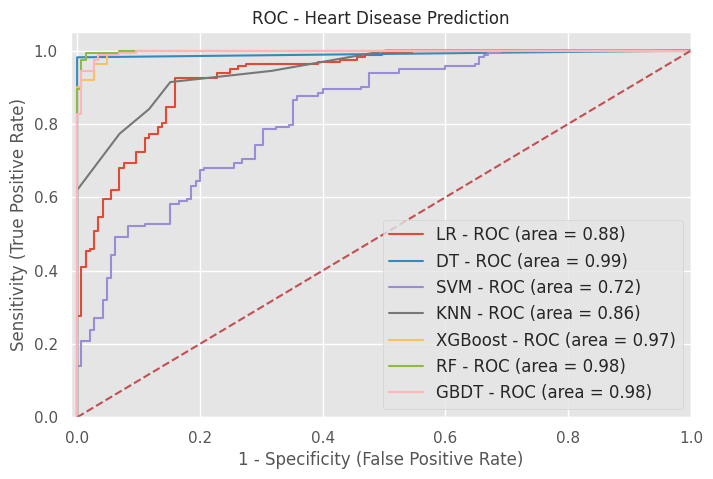

In [41]:
import os
import matplotlib.pyplot as plt
from sklearn import metrics

# Create the 'outputs' directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

# Plot the ROC curve
plt.figure(figsize=(8,5))

models = [
    {'label': 'LR', 'model': lr},
    {'label': 'DT', 'model': dtc2},
    {'label': 'SVM', 'model': svc},
    {'label': 'KNN', 'model': knn},
    {'label': 'XGBoost', 'model': xgb},
    {'label': 'RF', 'model': rfc},
    {'label': 'GBDT', 'model': gbc}
]

for m in models:
    model = m['model']
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test, model.predict_proba(x_test)[:, 1])
    auc = metrics.roc_auc_score(y_test, model.predict(x_test))
    plt.plot(fpr1, tpr1, label='%s - ROC (area = %0.2f)' % (m['label'], auc))

plt.plot([0, 1], [0, 1], 'r--')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity (False Positive Rate)', fontsize=12)
plt.ylabel('Sensitivity (True Positive Rate)', fontsize=12)
plt.title('ROC - Heart Disease Prediction', fontsize=12)
plt.legend(loc="lower right", fontsize=12)

# Save the plot
plt.savefig("outputs/roc_heart.jpeg", format='jpeg', dpi=400, bbox_inches='tight')

# Show the plot
plt.show()



[88.31, 99.68, 71.75, 86.04, 97.39999999999999, 98.7, 97.72999999999999]
[np.float64(88.03999999999999), np.float64(99.66000000000001), np.float64(71.89999999999999), np.float64(86.16), np.float64(97.28), np.float64(98.61999999999999), np.float64(97.66)]


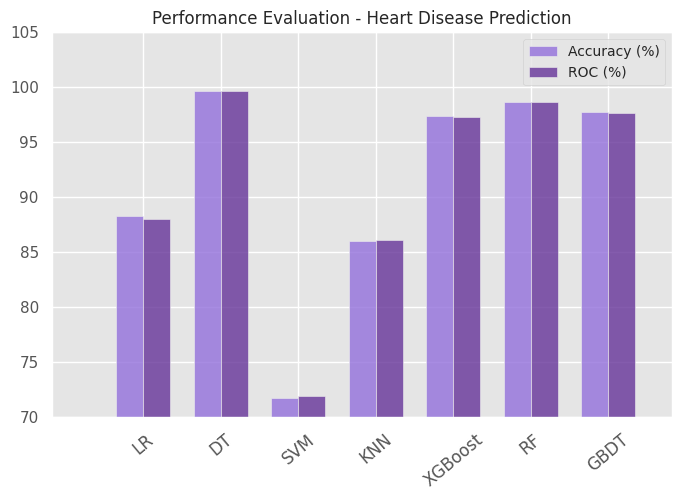

In [42]:
from sklearn import metrics
import numpy as np
import matplotlib.pyplot as plt

models = [
    {'label': 'LR', 'model': lr},
    {'label': 'DT', 'model': dtc2},
    {'label': 'SVM', 'model': svc},
    {'label': 'KNN', 'model': knn},
    {'label': 'XGBoost', 'model': xgb},
    {'label': 'RF', 'model': rfc},
    {'label': 'GBDT', 'model': gbc}
]

means_roc = []
means_accuracy = []

# Loop through the models and calculate accuracy and ROC AUC score
for m in models:
    model = m['model']
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)

    # Accuracy calculation
    accuracy = metrics.accuracy_score(y_test, y_pred)
    means_accuracy.append(100 * round(accuracy, 4))

    # ROC curve and AUC calculation
    fpr1, tpr1, thresholds = metrics.roc_curve(y_test, model.predict_proba(x_test)[:, 1])
    auc = metrics.roc_auc_score(y_test, model.predict(x_test))
    auc = 100 * round(auc, 4)
    means_roc.append(auc)

print(means_accuracy)
print(means_roc)

# Data to plot
n_groups = len(models)
means_accuracy = tuple(means_accuracy)
means_roc = tuple(means_roc)

# Create plot
fig, ax = plt.subplots(figsize=(8,5))
index = np.arange(n_groups)
bar_width = 0.35
opacity = 0.8

rects1 = plt.bar(index, means_accuracy, bar_width,
                 alpha=opacity,
                 color='mediumpurple',
                 label='Accuracy (%)')

rects2 = plt.bar(index + bar_width, means_roc, bar_width,
                 alpha=opacity,
                 color='rebeccapurple',
                 label='ROC (%)')

plt.xlim([-1, n_groups])
plt.ylim([70, 105])

plt.title('Performance Evaluation - Heart Disease Prediction', fontsize=12)
plt.xticks(index + bar_width / 2, ('LR', 'DT', 'SVM', 'KNN', 'XGBoost', 'RF', 'GBDT'), rotation=40, ha='center', fontsize=12)
plt.legend(loc="upper right", fontsize=10)

# Save the plot
plt.savefig("outputs/PE_heart.jpeg", format='jpeg', dpi=400, bbox_inches='tight')

# Show the plot
plt.show()



In [45]:
import pickle
import os

# Install onnx and skl2onnx if not already installed
!pip install onnx skl2onnx

import onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

os.makedirs('models', exist_ok=True)

models_to_save = [
    {'name': 'LogisticRegression', 'model': lr},
    {'name': 'DecisionTree', 'model': dtc2},
    {'name': 'SVM', 'model': svc},
    {'name': 'KNN', 'model': knn},
    {'name': 'XGBoost', 'model': xgb},
    {'name': 'RandomForest', 'model': rfc},
    {'name': 'GradientBoosting', 'model': gbc}
]

for item in models_to_save:
    model_name = item['name']
    model = item['model']
    file_path = f'models/{model_name}.pkl'
    with open(file_path, 'wb') as f:
        pickle.dump(model, f)
    print(f"Model '{model_name}' saved to {file_path}")


# Save the best model (Random Forest) in ONNX format

# Define initial types for ONNX conversion
# x_train is available and has numerical features
initial_type = [('float_input', FloatTensorType([None, x_train.shape[1]]))]

# Convert the Random Forest model to ONNX format
onx_model = convert_sklearn(rfc, initial_types=initial_type)

# Create outputs directory if it doesn't exist
os.makedirs('outputs', exist_ok=True)

# Save the ONNX model to a file
with open("outputs/random_forest_model.onnx", "wb") as f:
    f.write(onx_model.SerializeToString())

print("Best model (Random Forest) saved in ONNX format to outputs/random_forest_model.onnx")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 85.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 31.8 MB/s eta 0:00:00
Model 'LogisticRegression' saved to models/LogisticRegression.pkl
Model 'DecisionTree' saved to models/DecisionTree.pkl
Model 'SVM' saved to models/SVM.pkl
Model 'KNN' saved to models/KNN.pkl
Model 'XGBoost' saved to models/XGBoost.pkl
Model 'RandomForest' saved to models/RandomForest.pkl
Model 'GradientBoosting' saved to models/GradientBoosting.pkl
Best model (Random Forest) saved in ONNX format to outputs/random_forest_model.onnx
